In [1]:
!pip install pytorch-forecasting pytorch-lightning -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 62.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import torch
import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from google.colab import drive

In [3]:
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/vol_forecasting"

df = pd.read_parquet(f"{PROJECT_DIR}/features.parquet")
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Tickers: {df['ticker'].nunique()}")
print(f"Columns: {df.columns.tolist()}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

Mounted at /content/drive
Shape: (85750, 24)
Tickers: 50
Columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'ticker', 'company', 'sector', 'log_ret', 'real_vol', 'target', 'vol_lag1', 'vol_lag5', 'vol_lag20', 'ewma_vol', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'volume_ratio', 'vix', 'cap_bucket', 'time_idx']
Date range: 2018-03-01 → 2024-12-20


Preparing data for TFT

In [4]:
# TFT needs string categoricals
df["ticker"]     = df["ticker"].astype(str)
df["sector"]     = df["sector"].astype(str).fillna("Unknown")
df["cap_bucket"] = df["cap_bucket"].astype(str)

# Chronological split — never shuffle for time series
TRAIN_END = "2021-12-31"
VAL_END   = "2022-12-31"
# test = 2023–2024

df["split"] = "test"
df.loc[df["date"] <= TRAIN_END, "split"] = "train"
df.loc[(df["date"] > TRAIN_END) & (df["date"] <= VAL_END), "split"] = "val"

print(df["split"].value_counts())

split
train    48400
test     24800
val      12550
Name: count, dtype: int64


In [5]:
MAX_ENCODER_LENGTH    = 60  # model looks back 60 days
MAX_PREDICTION_LENGTH = 5   # predicts 5 days ahead

train_df = df[df["split"] == "train"].copy()

training = TimeSeriesDataSet(
    train_df,
    time_idx              = "time_idx",
    target                = "target",
    group_ids             = ["ticker"],
    max_encoder_length    = MAX_ENCODER_LENGTH,
    max_prediction_length = MAX_PREDICTION_LENGTH,

    # Static — same value for all timesteps of a ticker
    static_categoricals   = ["sector", "cap_bucket"],
    static_reals          = [],

    # Known future — you know these values ahead of time
    time_varying_known_reals = [
        "time_idx",
        "day_sin", "day_cos",
        "month_sin", "month_cos",
    ],

    # Unknown future — only observable up to today
    time_varying_unknown_reals = [
        "real_vol",
        "vol_lag1", "vol_lag5", "vol_lag20",
        "ewma_vol",
        "vix",
        "volume_ratio",
        "log_ret",
    ],

    target_normalizer = GroupNormalizer(
        groups=["ticker"], transformation="softplus"
    ),
    add_relative_time_idx = True,
    add_target_scales     = True,
    add_encoder_length    = True,
)

# Val and test share the normalizer from training — critical, no data leakage
validation = TimeSeriesDataSet.from_dataset(
    training, df[df["split"] == "val"].copy(),
    predict=False, stop_randomization=True
)
testing = TimeSeriesDataSet.from_dataset(
    training, df[df["split"] == "test"].copy(),
    predict=False, stop_randomization=True
)

print(f"Train samples: {len(training)}")
print(f"Val samples:   {len(validation)}")
print(f"Test samples:  {len(testing)}")

Train samples: 45200
Val samples:   9350
Test samples:  21600


In [6]:
BATCH_SIZE = 128

train_loader = training.to_dataloader(
    train=True,  batch_size=BATCH_SIZE, num_workers=2
)
val_loader = validation.to_dataloader(
    train=False, batch_size=BATCH_SIZE, num_workers=2
)
test_loader = testing.to_dataloader(
    train=False, batch_size=BATCH_SIZE, num_workers=2
)

# Sanity check — one batch
x, y = next(iter(train_loader))
print(f"Batch x keys:  {list(x.keys())}")
print(f"Batch y shape: {y[0].shape}")
# y shape should be (batch_size, 5) — 5 = prediction length

Batch x keys:  ['encoder_cat', 'encoder_cont', 'encoder_target', 'encoder_lengths', 'decoder_cat', 'decoder_cont', 'decoder_target', 'decoder_lengths', 'decoder_time_idx', 'groups', 'target_scale']
Batch y shape: torch.Size([128, 5])


Defining TFT

In [7]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate          = 1e-3,
    hidden_size            = 32,
    attention_head_size    = 2,
    dropout                = 0.1,
    hidden_continuous_size = 16,
    loss                   = QuantileLoss([0.1, 0.5, 0.9]),
    log_interval           = 10,
    optimizer              = "adam",
    reduce_on_plateau_patience = 4,
)

total_params = sum(p.numel() for p in tft.parameters())
print(f"Model parameters: {total_params:,}")

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


Model parameters: 101,061


In [8]:
# Make sure you have GPU: Runtime → Change runtime type → T4 GPU
print("GPU available:", torch.cuda.is_available())

trainer = pl.Trainer(
    max_epochs        = 30,
    accelerator       = "gpu" if torch.cuda.is_available() else "cpu",
    gradient_clip_val = 0.1,
    callbacks         = [
        pl.callbacks.EarlyStopping(
            monitor  = "val_loss",
            patience = 5,
            mode     = "min"
        ),
        pl.callbacks.ModelCheckpoint(
            monitor   = "val_loss",
            dirpath   = PROJECT_DIR,
            filename  = "tft_best",
            save_top_k= 1,
            mode      = "min"
        ),
    ],
    logger = False,
    enable_progress_bar = True,
)

trainer.fit(tft, train_loader, val_loader)
print("Training complete.")
print(f"Best val loss: {trainer.checkpoint_callback.best_model_score:.4f}")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


GPU available: True


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/vol_forecasting exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     54 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    544 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.1 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 29.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 11.9 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     99 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 101 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 101 K                                                                                                
Total estimated model params size (MB): 0.404                                                                      
Modules in train mode: 506                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Training complete.
Best val loss: 0.0322


validation

In [9]:
import os
ckpt_path = f"{PROJECT_DIR}/tft_best.ckpt"
if os.path.exists(ckpt_path):
    size = os.path.getsize(ckpt_path) / 1e6
    print(f"✅ Checkpoint saved  ({size:.1f} MB)")
else:
    print("❌ Checkpoint not found")

✅ Checkpoint saved  (1.8 MB)


In [10]:
best_model = TemporalFusionTransformer.load_from_checkpoint(
    f"{PROJECT_DIR}/tft_best.ckpt"
)
best_model.eval()

# Generate predictions on test set
predictions = best_model.predict(
    test_loader,
    mode         = "quantiles",
    return_index = True,
)

# predictions is a named tuple — extract parts
pred_output = predictions.output   # shape (n_samples, horizon, 3) — p10, p50, p90
pred_index  = predictions.index    # DataFrame with ticker, time_idx per sample

print(f"Prediction output shape: {pred_output.shape}")
print(f"Index shape: {pred_index.shape}")
print(f"Index columns: {pred_index.columns.tolist()}")
print(pred_index.head())

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

Prediction output shape: torch.Size([21600, 5, 3])
Index shape: (21600, 2)
Index columns: ['time_idx', 'ticker']
   time_idx ticker
0      1319   AAPL
1      1320   AAPL
2      1321   AAPL
3      1322   AAPL
4      1323   AAPL


In [11]:
p10 = pred_output[:, :, 0].numpy()  # lower bound
p50 = pred_output[:, :, 1].numpy()  # median — main forecast
p90 = pred_output[:, :, 2].numpy()  # upper bound

print(f"p50 sample (first 3 predictions, all 5 days):\n{p50[:3]}")

p50 sample (first 3 predictions, all 5 days):
[[0.23937194 0.24498288 0.24416897 0.24267165 0.24098292]
 [0.23103815 0.23123477 0.23065524 0.229674   0.23032543]
 [0.22178987 0.22252697 0.22262481 0.223929   0.22466156]]


In [12]:
def rmse(a, p): return round(np.sqrt(mean_squared_error(a, p)), 4)
def mae(a, p):  return round(mean_absolute_error(a, p), 4)

actuals_list = []
p50_list     = []
p10_list     = []
p90_list     = []

for i in range(len(pred_index)):
    ticker   = pred_index.iloc[i]["ticker"]
    time_idx = pred_index.iloc[i]["time_idx"]

    actual_rows = df[
        (df["ticker"]   == ticker) &
        (df["time_idx"] >= time_idx) &
        (df["time_idx"] <  time_idx + MAX_PREDICTION_LENGTH)
    ]["target"].values

    pred_p50 = p50[i]
    pred_p10 = p10[i]
    pred_p90 = p90[i]

    min_len = min(len(actual_rows), len(pred_p50))
    if min_len == 0:
        continue

    actuals_list.extend(actual_rows[:min_len].tolist())
    p50_list.extend(pred_p50[:min_len].tolist())
    p10_list.extend(pred_p10[:min_len].tolist())
    p90_list.extend(pred_p90[:min_len].tolist())

actuals_arr = np.array(actuals_list)
p50_arr     = np.array(p50_list)
p10_arr     = np.array(p10_list)
p90_arr     = np.array(p90_list)

# Coverage — % of actuals that fall inside p10–p90 band
# A well calibrated model should be close to 80%
coverage = np.mean((actuals_arr >= p10_arr) & (actuals_arr <= p90_arr))
avg_width = np.mean(p90_arr - p10_arr)

print(f"Samples matched: {len(actuals_arr):,}")
print(f"Coverage (p10–p90): {coverage:.1%}  (target ~80%)")
print(f"Avg interval width: {avg_width:.4f}")

Samples matched: 108,000
Coverage (p10–p90): 76.9%  (target ~80%)
Avg interval width: 0.1088


In [13]:
baseline = pd.read_parquet(f"{PROJECT_DIR}/baseline_results.parquet")
baseline_mean = baseline.mean(numeric_only=True).round(4)

comparison = pd.DataFrame({
    "Model": [
        "Random Walk",
        "Hist Average",
        "EWMA",
        "GARCH(1,1)",
        "TFT (p50)",
    ],
    "RMSE": [
        baseline_mean["rw_rmse"],
        baseline_mean["hist_rmse"],
        baseline_mean["ewma_rmse"],
        baseline_mean["garch_rmse"],
        rmse(actuals_arr, p50_arr),
    ],
    "MAE": [
        baseline_mean["rw_mae"],
        baseline_mean["hist_mae"],
        baseline_mean["ewma_mae"],
        baseline_mean["garch_mae"],
        mae(actuals_arr, p50_arr),
    ],
})

print("=" * 42)
print("       FINAL RESULTS TABLE")
print("=" * 42)
print(comparison.to_string(index=False))
print("=" * 42)
print(f"TFT Coverage (p10-p90): {coverage:.1%}")
print(f"TFT Avg Interval Width: {avg_width:.4f}")

       FINAL RESULTS TABLE
       Model   RMSE    MAE
 Random Walk 0.0240 0.0107
Hist Average 0.0795 0.0602
        EWMA 0.0373 0.0269
  GARCH(1,1) 0.0751 0.0558
   TFT (p50) 0.0602 0.0394
TFT Coverage (p10-p90): 76.9%
TFT Avg Interval Width: 0.1088


plot

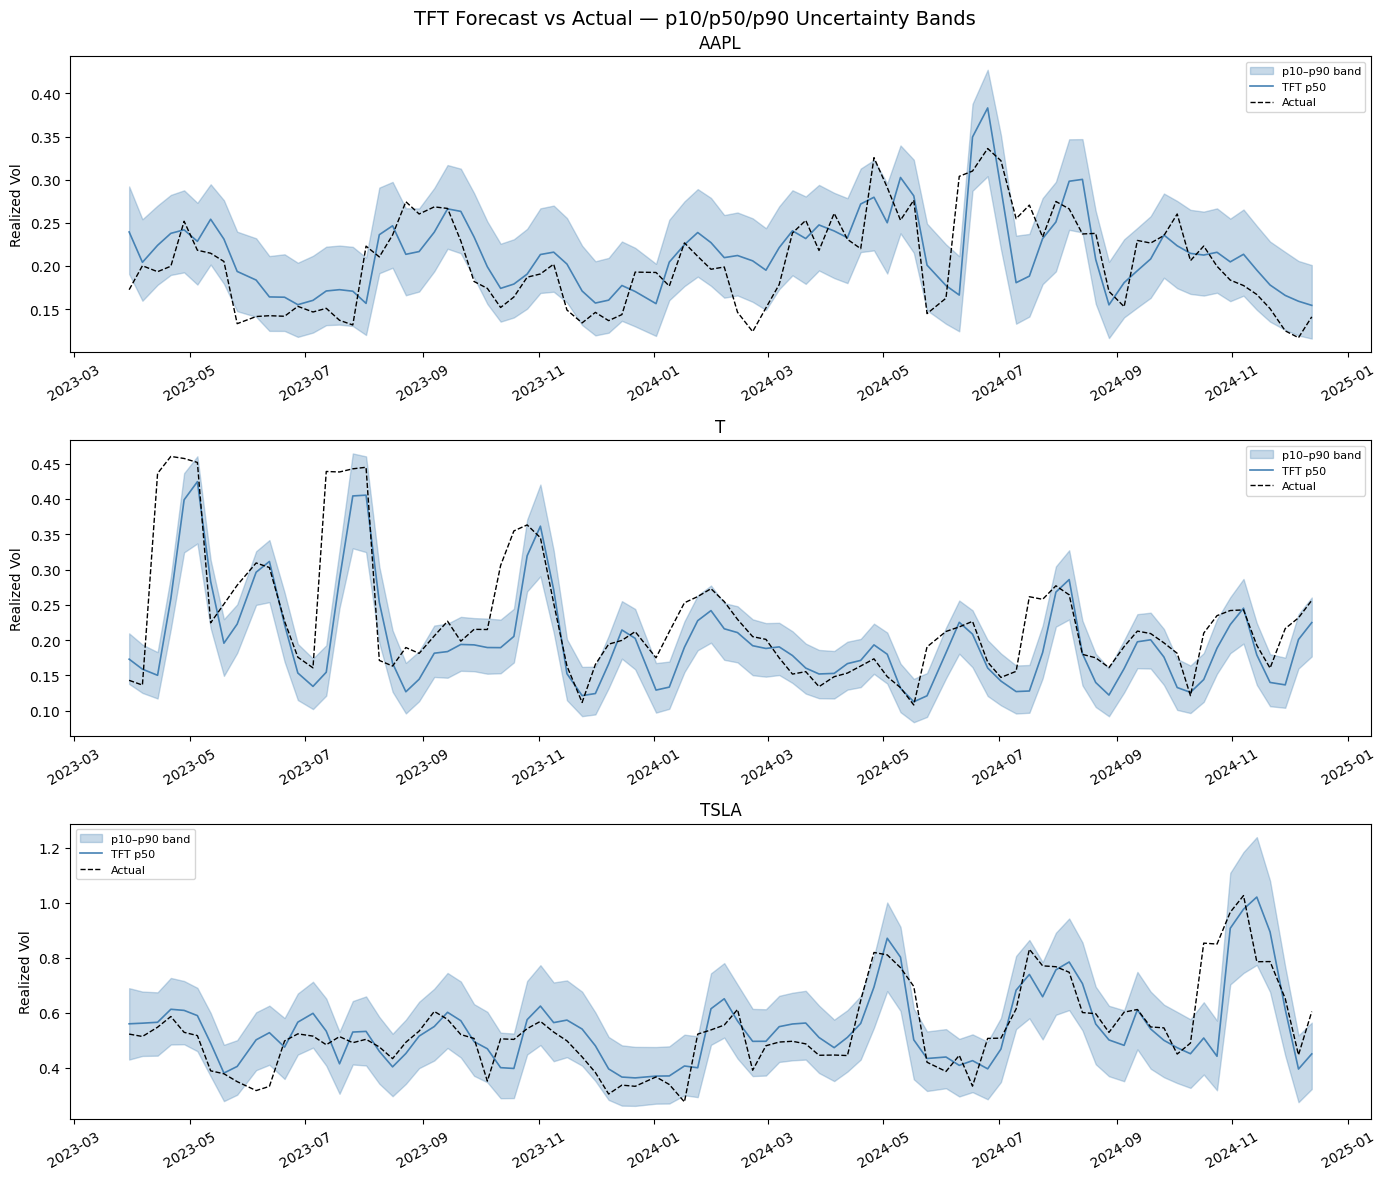

In [14]:
tickers_to_plot = ["AAPL", "T", "TSLA"]
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, ticker in zip(axes, tickers_to_plot):
    # Get all prediction indices for this ticker
    mask = pred_index["ticker"] == ticker
    ticker_positions = np.where(mask.values)[0]

    if len(ticker_positions) == 0:
        ax.set_title(f"{ticker} — no predictions found")
        continue

    # Use every 5th prediction to avoid overlapping windows
    ticker_positions = ticker_positions[::5]

    dates, actuals, p10s, p50s, p90s = [], [], [], [], []

    for i in ticker_positions:
        time_idx = pred_index.iloc[i]["time_idx"]

        actual_rows = df[
            (df["ticker"]   == ticker) &
            (df["time_idx"] == time_idx)
        ]
        if len(actual_rows) == 0:
            continue

        dates.append(actual_rows["date"].values[0])
        actuals.append(actual_rows["target"].values[0])
        p10s.append(float(p10[i, 0]))
        p50s.append(float(p50[i, 0]))
        p90s.append(float(p90[i, 0]))

    dates   = pd.to_datetime(dates)
    actuals = np.array(actuals)
    p10s    = np.array(p10s)
    p50s    = np.array(p50s)
    p90s    = np.array(p90s)

    ax.fill_between(dates, p10s, p90s,
                    alpha=0.3, color="steelblue", label="p10–p90 band")
    ax.plot(dates, p50s,    color="steelblue", lw=1.2, label="TFT p50")
    ax.plot(dates, actuals, color="black",     lw=1,   label="Actual", ls="--")
    ax.set_title(f"{ticker}")
    ax.set_ylabel("Realized Vol")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("TFT Forecast vs Actual — p10/p50/p90 Uncertainty Bands", fontsize=14)
plt.tight_layout()
plt.show()

Applying MAPIE to improve

In [15]:
# Step 1 — Get TFT predictions on the VALIDATION set
val_preds = best_model.predict(
    val_loader,
    mode         = "quantiles",
    return_index = True,
)

val_output = val_preds.output.numpy()   # (n, 5, 3)
val_index  = val_preds.index

val_p50 = val_output[:, :, 1]  # median predictions on val set

# Step 2 — Compute residuals on val set
val_actuals = []
val_p50_flat = []

for i in range(len(val_index)):
    ticker   = val_index.iloc[i]["ticker"]
    time_idx = val_index.iloc[i]["time_idx"]

    actual_rows = df[
        (df["ticker"]   == ticker) &
        (df["time_idx"] >= time_idx) &
        (df["time_idx"] <  time_idx + MAX_PREDICTION_LENGTH)
    ]["target"].values

    pred = val_p50[i]
    min_len = min(len(actual_rows), len(pred))
    if min_len == 0:
        continue

    val_actuals.extend(actual_rows[:min_len].tolist())
    val_p50_flat.extend(pred[:min_len].tolist())

val_actuals  = np.array(val_actuals)
val_p50_flat = np.array(val_p50_flat)

# Residuals — absolute errors on val set
residuals = np.abs(val_actuals - val_p50_flat)

print(f"Val samples: {len(residuals):,}")
print(f"Mean residual: {residuals.mean():.4f}")
print(f"80th percentile residual: {np.quantile(residuals, 0.80):.4f}")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Val samples: 46,750
Mean residual: 0.0461
80th percentile residual: 0.0660


Applying conformational correction

In [16]:
# The conformal quantile — this is Q
# Using 80% target coverage
COVERAGE_TARGET = 0.80
Q = np.quantile(residuals, COVERAGE_TARGET)
print(f"Conformal correction Q (80%): {Q:.4f}")

# Apply to test predictions — widen or narrow TFT's intervals
# by the correction factor
conformal_lower = p50_arr - Q
conformal_upper = p50_arr + Q

# Clip lower bound at 0 — volatility can't be negative
conformal_lower = np.clip(conformal_lower, 0, None)

# New coverage
conformal_coverage = np.mean(
    (actuals_arr >= conformal_lower) &
    (actuals_arr <= conformal_upper)
)
conformal_width = np.mean(conformal_upper - conformal_lower)

print(f"\n{'':=<45}")
print(f"  BEFORE conformal:  coverage={coverage:.1%}  width={avg_width:.4f}")
print(f"  AFTER  conformal:  coverage={conformal_coverage:.1%}  width={conformal_width:.4f}")
print(f"{'':=<45}")

Conformal correction Q (80%): 0.0660

  BEFORE conformal:  coverage=76.9%  width=0.1088
  AFTER  conformal:  coverage=84.6%  width=0.1319


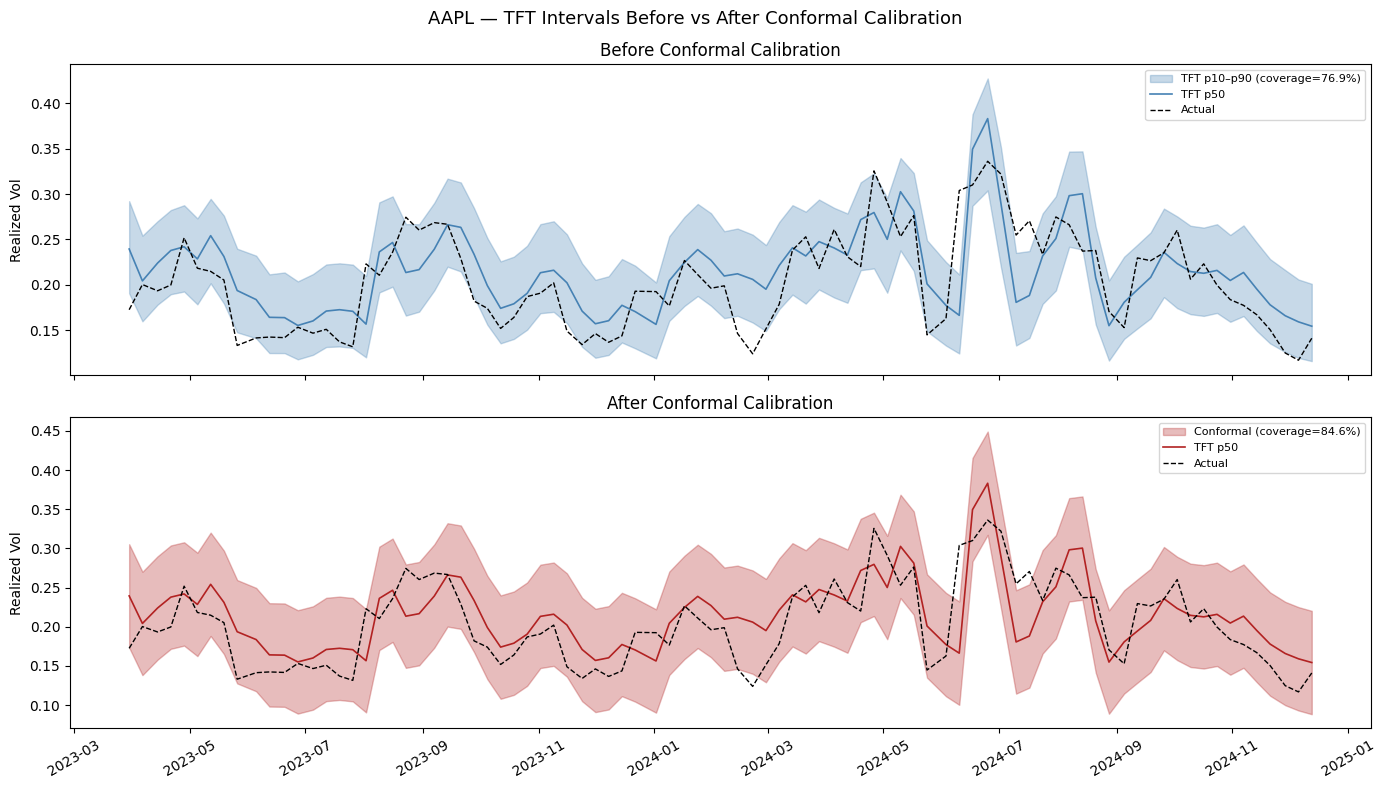

In [17]:
ticker = "AAPL"
mask   = pred_index["ticker"] == ticker
positions = np.where(mask.values)[0][::5]

dates, acts, orig_lo, orig_hi, conf_lo, conf_hi, p50s = [], [], [], [], [], [], []

for i in positions:
    time_idx = pred_index.iloc[i]["time_idx"]
    row = df[(df["ticker"] == ticker) & (df["time_idx"] == time_idx)]
    if len(row) == 0:
        continue

    # Find position in flattened arrays
    flat_i = i  # one-to-one for first step of each prediction window

    dates.append(row["date"].values[0])
    acts.append(row["target"].values[0])
    orig_lo.append(float(p10[i, 0]))
    orig_hi.append(float(p90[i, 0]))
    conf_lo.append(max(0, float(p50[i, 0]) - Q))
    conf_hi.append(float(p50[i, 0]) + Q)
    p50s.append(float(p50[i, 0]))

dates   = pd.to_datetime(dates)
acts    = np.array(acts)
orig_lo = np.array(orig_lo)
orig_hi = np.array(orig_hi)
conf_lo = np.array(conf_lo)
conf_hi = np.array(conf_hi)
p50s    = np.array(p50s)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Original TFT intervals
ax1.fill_between(dates, orig_lo, orig_hi,
                 alpha=0.3, color="steelblue", label=f"TFT p10–p90 (coverage={coverage:.1%})")
ax1.plot(dates, p50s, color="steelblue", lw=1.2, label="TFT p50")
ax1.plot(dates, acts, color="black", lw=1, ls="--", label="Actual")
ax1.set_title("Before Conformal Calibration")
ax1.set_ylabel("Realized Vol")
ax1.legend(fontsize=8)

# Conformal intervals
ax2.fill_between(dates, conf_lo, conf_hi,
                 alpha=0.3, color="firebrick", label=f"Conformal (coverage={conformal_coverage:.1%})")
ax2.plot(dates, p50s, color="firebrick", lw=1.2, label="TFT p50")
ax2.plot(dates, acts, color="black", lw=1, ls="--", label="Actual")
ax2.set_title("After Conformal Calibration")
ax2.set_ylabel("Realized Vol")
ax2.legend(fontsize=8)
ax2.tick_params(axis="x", rotation=30)

plt.suptitle("AAPL — TFT Intervals Before vs After Conformal Calibration", fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
batch = next(iter(test_loader))
best_model.eval()
with torch.no_grad():
    output = best_model(batch[0])  # batch[0] = x, batch[1] = y

interpretation = best_model.interpret_output(
    output,
    reduction="sum"
)

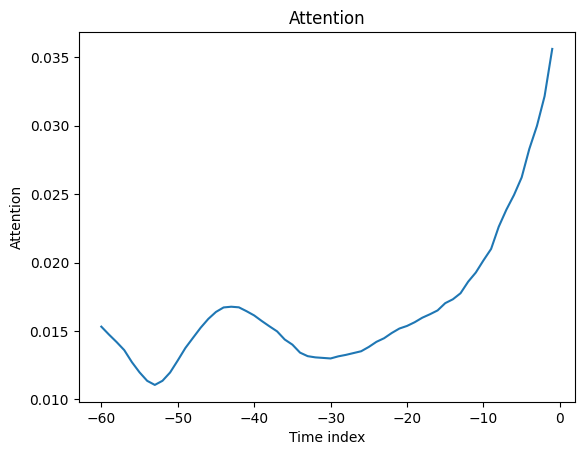

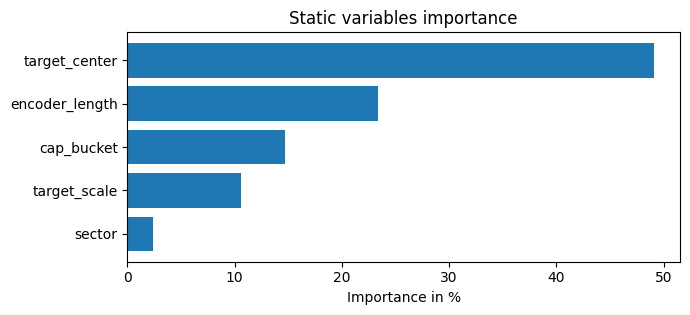

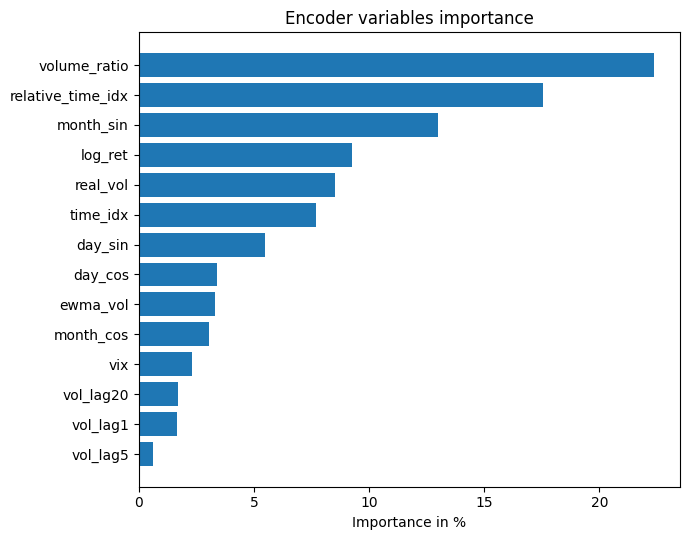

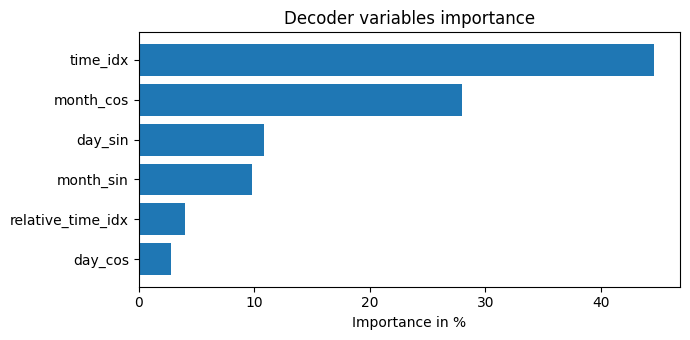

In [20]:
best_model.plot_interpretation(interpretation)
plt.show()

Fixing overcorrection (interval may be too wide )

In [22]:
for target_q in [0.72, 0.74, 0.75, 0.76, 0.77]:
    Q = np.quantile(residuals, target_q)
    conf_lower = np.clip(p50_arr - Q, 0, None)
    conf_upper = p50_arr + Q
    cov = np.mean((actuals_arr >= conf_lower) & (actuals_arr <= conf_upper))
    print(f"quantile={target_q}  Q={Q:.4f}  coverage={cov:.1%}")

quantile=0.72  Q=0.0531  coverage=77.0%
quantile=0.74  Q=0.0559  coverage=79.0%
quantile=0.75  Q=0.0574  coverage=79.9%
quantile=0.76  Q=0.0590  coverage=80.9%
quantile=0.77  Q=0.0605  coverage=81.8%


In [23]:
Q_FINAL = np.quantile(residuals, 0.75)

conformal_lower = np.clip(p50_arr - Q_FINAL, 0, None)
conformal_upper = p50_arr + Q_FINAL

final_coverage = np.mean(
    (actuals_arr >= conformal_lower) &
    (actuals_arr <= conformal_upper)
)
final_width = np.mean(conformal_upper - conformal_lower)

print(f"Final Q:        {Q_FINAL:.4f}")
print(f"Final coverage: {final_coverage:.1%}")
print(f"Final width:    {final_width:.4f}")

Final Q:        0.0574
Final coverage: 79.9%
Final width:    0.1147


Pushing

In [32]:
import os

# Search for all notebooks in the Colab VM
for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith('.ipynb'):
            print(os.path.join(root, file))

/content/drive/MyDrive/assignment_3.ipynb
/content/drive/MyDrive/Colab Notebooks/first.ipynb
/content/drive/MyDrive/Colab Notebooks/day17.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled6.ipynb
/content/drive/MyDrive/Colab Notebooks/ML_ASS1.ipynb
/content/drive/MyDrive/Colab Notebooks/tensor.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled7.ipynb
/content/drive/MyDrive/Colab Notebooks/ML_ASS2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled8.ipynb
/content/drive/MyDrive/Colab Notebooks/ML_ASS3.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled9.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled10.ipynb
/content/drive/MyDrive/Colab Notebooks/

In [33]:
import shutil

shutil.copy(
    "/content/drive/MyDrive/Colab Notebooks/Project_volatility.ipynb",
    "/content/drive/MyDrive/vol_forecasting/Project_volatility.ipynb"
)
shutil.copy(
    "/content/drive/MyDrive/Colab Notebooks/TFT.ipynb",
    "/content/drive/MyDrive/vol_forecasting/TFT.ipynb"
)
print("Both notebooks copied to vol_forecasting folder")

Both notebooks copied to vol_forecasting folder


In [42]:
from google.colab import userdata
GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")
print("Token loaded:", GITHUB_TOKEN[:4] + "****")

Token loaded: ghp_****


In [43]:
from google.colab import userdata

GITHUB_USERNAME = "Ved130"
GITHUB_TOKEN    = userdata.get("GITHUB_TOKEN")
REPO_NAME       = "Volatality_predication"

# Remove old clone if it exists from previous attempt
!rm -rf /content/{REPO_NAME}

!git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git /content/{REPO_NAME}
!mkdir -p /content/{REPO_NAME}/notebooks
!cp "/content/drive/MyDrive/vol_forecasting/Project_volatility.ipynb" /content/{REPO_NAME}/notebooks/
!cp "/content/drive/MyDrive/vol_forecasting/TFT.ipynb" /content/{REPO_NAME}/notebooks/

%cd /content/{REPO_NAME}
!git config user.email "pashine@email.com"
!git config user.name "Ved130"
!git add notebooks/
!git commit -m "add volatility forecasting notebooks"
!git push

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
Cloning into '/content/Volatality_predication'...
fatal: Unable to read current working directory: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
/content/Volatality_predication
fatal: not in a git directory
fatal: not in a git directory
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
